# Reporter Assay Analysis

Turns a reporter assay spreadsheet (e.g. luciferase) into tidy data, summary statistics and publication-style plots.

It compares **conditions** (transcription factors alone, in combination, and controls) across **doses**, with every replicate shown as a point on top of the bars.

**Expected spreadsheet layout** (one sheet, no extra header rows):

| Row | Content |
|-----|---------|
| 1 | Condition name, written above the first dose column of each condition |
| 2 | Dose for each column (e.g. `25 ng`, `50 ng`, `100 ng`) |
| 3+ | One row per biological replicate (blank cells are allowed) |

The included `data/example_reporter_assay.xlsx` is **synthetic data** generated for demonstration.

## 1. Settings

In [1]:
DATA_FILE = "data/example_reporter_assay.xlsx"   # path to your spreadsheet
BASELINE = "Reporter only"                       # condition used as the reference (fold change and statistics)
SAVE_FIGURES = True                              # save plots as PNG into FIGURE_DIR
FIGURE_DIR = "figures"                           # images (the README shows these)
RESULT_DIR = "results"                           # CSVs this run produces

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="talk")
Path(FIGURE_DIR).mkdir(exist_ok=True)
Path(RESULT_DIR).mkdir(exist_ok=True)


def figure_path(filename):
    """Where to save a figure, or None when SAVE_FIGURES is off."""
    return Path(FIGURE_DIR) / filename if SAVE_FIGURES else None

## 2. Load and tidy the data

The two header rows are combined into one label per column, text values are converted to numbers, and the table is reshaped to *long* format (one row per measurement), which makes grouping and plotting straightforward.

In [3]:
def load_plate(path):
    raw = pd.read_excel(path, header=None)
    conditions = raw.iloc[0].ffill()          # fill the condition name across its dose columns
    doses = raw.iloc[1].astype(str).str.strip()
    values = raw.iloc[2:].apply(pd.to_numeric, errors="coerce").reset_index(drop=True)

    columns = pd.DataFrame({"condition": conditions.str.strip(), "dose": doses})
    # dose level = position of the dose within its condition (1 = lowest), so combinations
    # like "12.5 ng each" line up with the matching single-factor dose
    columns["dose_level"] = columns.groupby("condition").cumcount() + 1
    columns["label"] = columns["condition"] + " " + columns["dose"]

    values.columns = columns["label"]
    tidy = (values.rename_axis("replicate").reset_index()
                  .melt(id_vars="replicate", var_name="label", value_name="value")
                  .merge(columns, on="label")
                  .dropna(subset=["value"]))
    tidy["replicate"] += 1
    return values, tidy, columns

wide, tidy, layout = load_plate(DATA_FILE)
wide

label,TF-A 25 ng,TF-A 50 ng,TF-A 100 ng,TF-B 25 ng,TF-B 50 ng,TF-B 100 ng,TF-A + TF-B 12.5 ng each,TF-A + TF-B 25 ng each,TF-A + TF-B 50 ng each,GFP control 25 ng,GFP control 50 ng,GFP control 100 ng,Reporter only 100 ng
0,1.800,2.229,2.914,1.426,1.916,2.322,2.205,3.729,5.164,0.957,0.921,0.889,0.997
1,1.843,2.313,3.211,1.559,1.759,1.963,2.332,3.415,5.024,0.996,1.010,1.031,1.071
2,1.761,2.210,NaN,1.543,1.896,2.119,2.217,3.882,4.073,1.009,0.968,0.889,0.953


In [4]:
missing = wide.isna().sum()
if missing.any():
    print("Missing replicates:")
    print(missing[missing > 0].to_string())

Missing replicates:
label
TF-A 100 ng    1


## 3. Summary statistics

Mean, standard deviation, number of replicates, and fold change relative to the baseline condition.

In [5]:
baseline_mean = tidy.loc[tidy["condition"] == BASELINE, "value"].mean()

summary = (tidy.groupby(["condition", "dose", "dose_level", "label"], sort=False)["value"]
               .agg(mean="mean", sd="std", n="count")
               .reset_index())
summary["fold_vs_baseline"] = summary["mean"] / baseline_mean
summary.round(3)

,condition,dose,dose_level,label,mean,sd,n,fold_vs_baseline
0,TF-A,25 ng,1,TF-A 25 ng,1.801,0.041,3,1.789
1,TF-A,50 ng,2,TF-A 50 ng,2.251,0.055,3,2.235
2,TF-A,100 ng,3,TF-A 100 ng,3.062,0.210,2,3.041
3,TF-B,25 ng,1,TF-B 25 ng,1.509,0.073,3,1.499
4,TF-B,50 ng,2,TF-B 50 ng,1.857,0.085,3,1.844
5,TF-B,100 ng,3,TF-B 100 ng,2.135,0.180,3,2.120
6,TF-A + TF-B,12.5 ng each,1,TF-A + TF-B 12.5 ng each,2.251,0.070,3,2.236
7,TF-A + TF-B,25 ng each,2,TF-A + TF-B 25 ng each,3.675,0.238,3,3.650
8,TF-A + TF-B,50 ng each,3,TF-A + TF-B 50 ng each,4.754,0.594,3,4.721
9,GFP control,25 ng,1,GFP control 25 ng,0.987,0.027,3,0.980


## 4. Overview: all conditions

Bars show the mean ± standard deviation; black points are individual replicates. The dashed line marks the baseline mean.

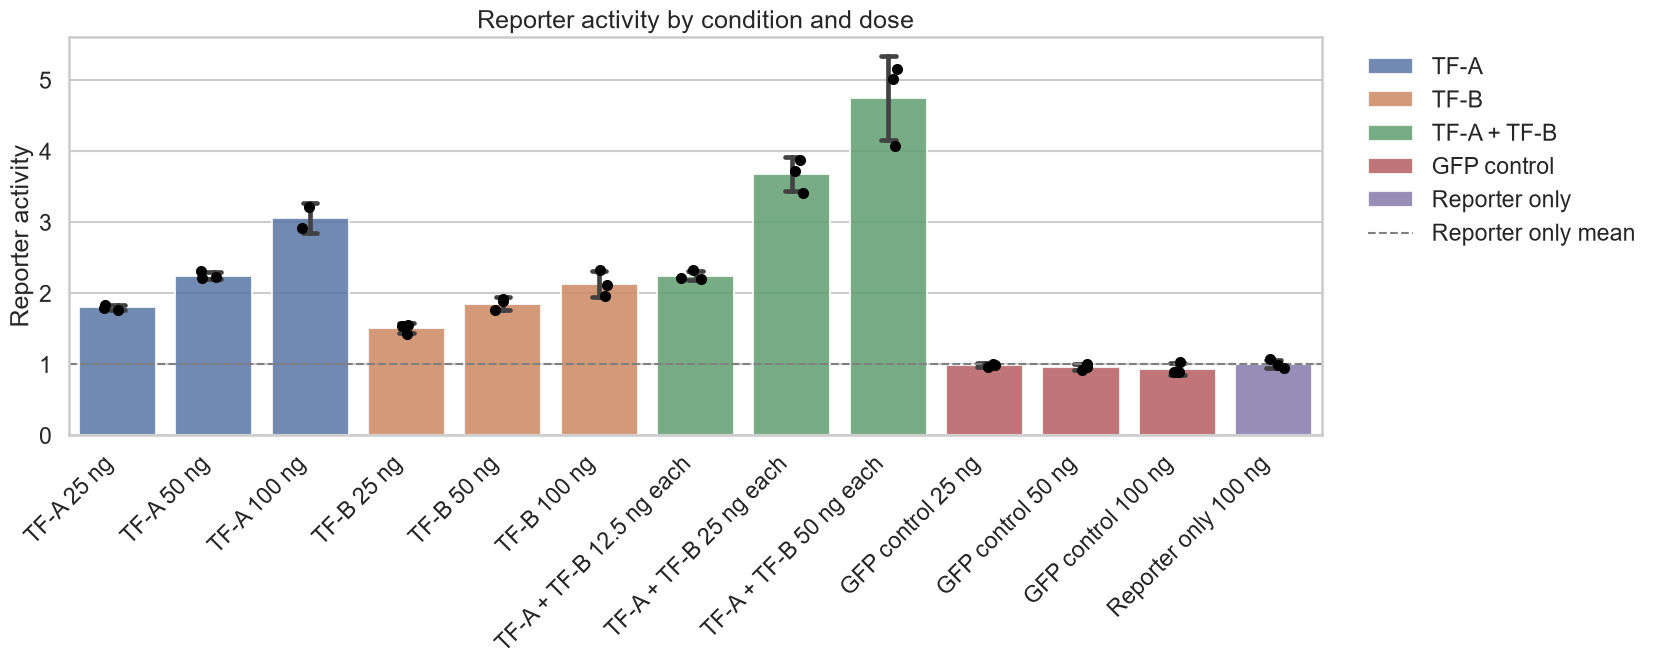

In [6]:
def bar_with_points(data, title, reference, reference_label,
                    order=None, save_as=None):
    """Bars of mean ± SD with every replicate on top, and the reference mean marked.

    Everything it draws is an argument, so the same function works for a subset,
    another dataset, or a different reference condition.
    """
    fig, ax = plt.subplots(figsize=(max(8, 1.3 * data["label"].nunique()), 7))
    sns.barplot(data=data, x="label", y="value", hue="condition", order=order,
                dodge=False, capsize=0.15, errorbar="sd", alpha=0.85, ax=ax)
    sns.stripplot(data=data, x="label", y="value", order=order, color="black",
                  size=8, jitter=0.15, ax=ax)
    ax.axhline(reference, ls="--", color="grey", lw=1.5, label=f"{reference_label} mean")
    ax.set(title=title, xlabel="", ylabel="Reporter activity")
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=200, bbox_inches="tight")
    plt.show()


bar_with_points(tidy, "Reporter activity by condition and dose",
                reference=baseline_mean, reference_label=BASELINE,
                order=layout["label"], save_as=figure_path("overview_bar.png"))

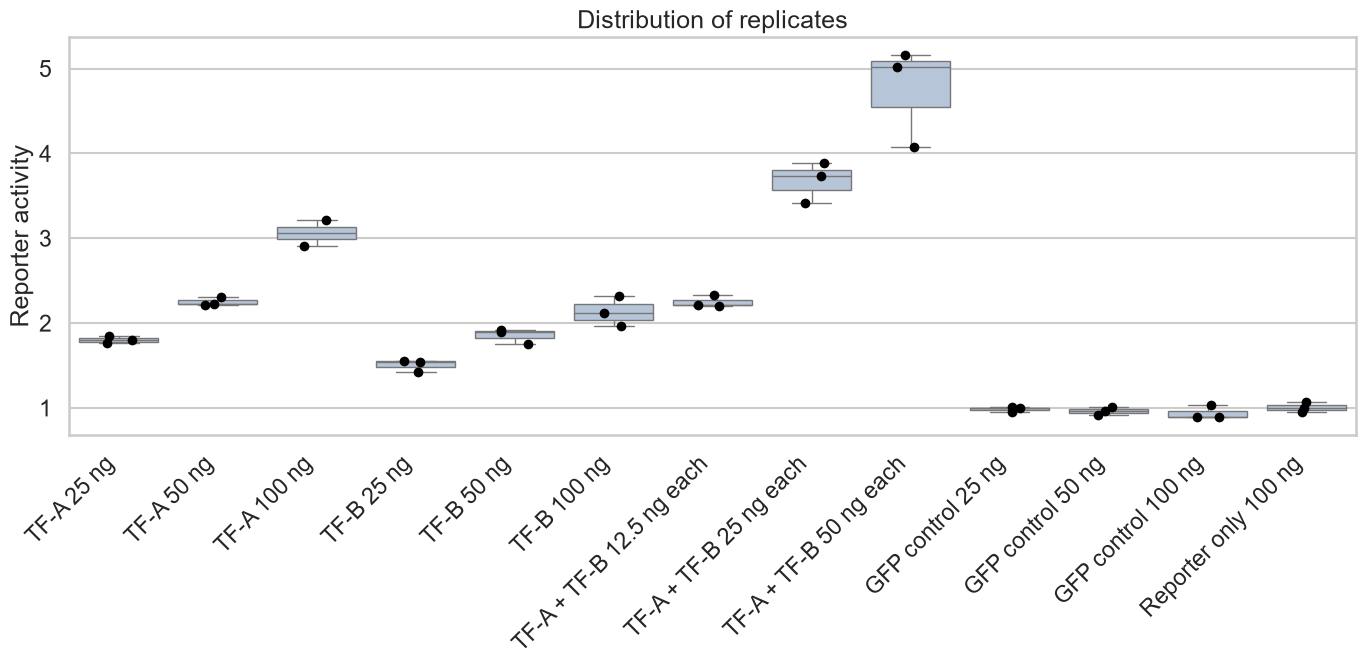

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=tidy, x="label", y="value", order=layout["label"], color="lightsteelblue", ax=ax)
sns.stripplot(data=tidy, x="label", y="value", order=layout["label"], color="black", size=7, jitter=0.15, ax=ax)
ax.set(title="Distribution of replicates", xlabel="", ylabel="Reporter activity")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(Path(FIGURE_DIR) / "overview_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Compare conditions at each dose level

Each plot puts every condition at the same dose level side by side, with the baseline condition included for reference.

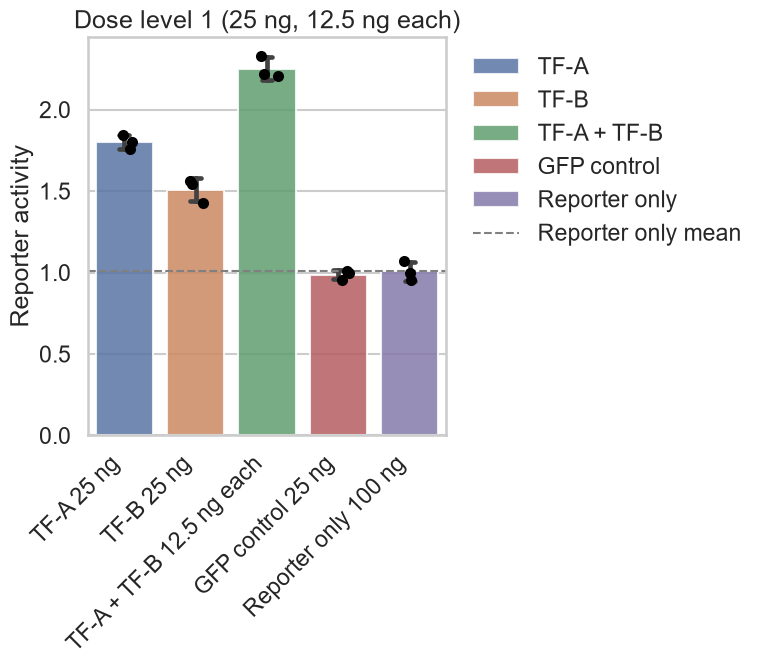

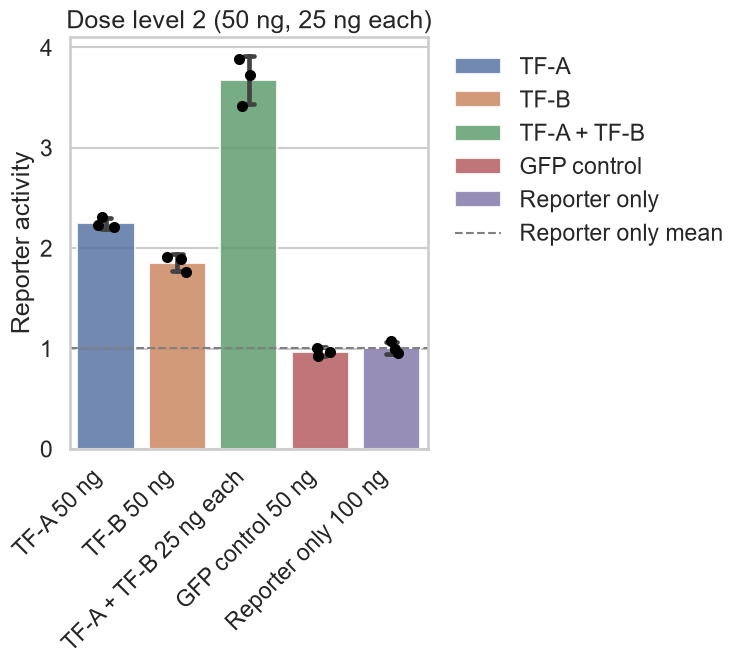

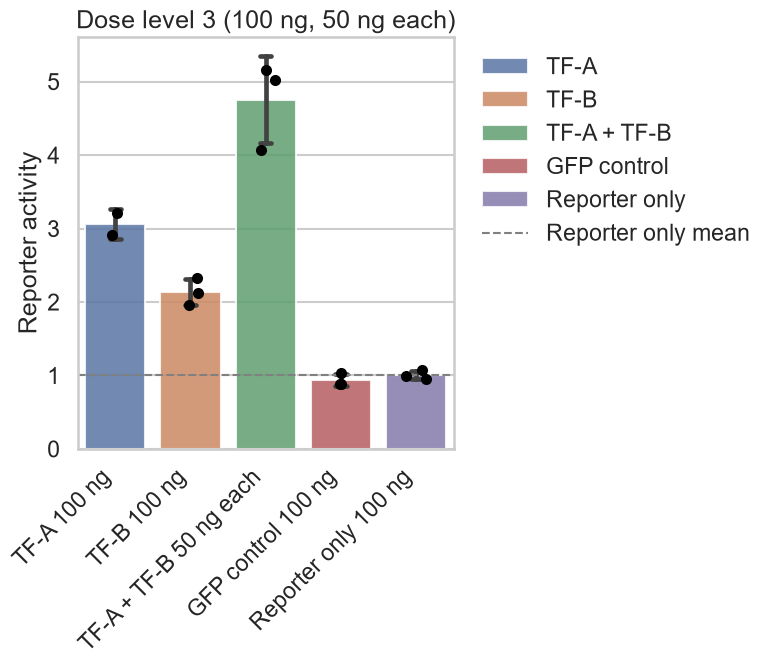

In [8]:
levels = sorted(tidy.loc[tidy["condition"] != BASELINE, "dose_level"].unique())
baseline_rows = tidy[tidy["condition"] == BASELINE]

for level in levels:
    subset = pd.concat([tidy[(tidy["dose_level"] == level) & (tidy["condition"] != BASELINE)], baseline_rows])
    order = list(dict.fromkeys(subset["label"]))
    names = ", ".join(subset.loc[subset["condition"] != BASELINE, "dose"].unique())
    bar_with_points(subset, f"Dose level {level} ({names})",
                    reference=baseline_mean, reference_label=BASELINE, order=order,
                    save_as=figure_path(f"dose_level_{level}.png"))

## 6. Statistics vs. baseline

Three views of the same comparison:

- a **one-way ANOVA** across every group, as an omnibus check that the conditions differ at all;
- **Dunnett's test**, which compares each condition against the baseline and controls the
  family-wise error rate for exactly that many-against-one design;
- **Welch's t-test** per condition, unadjusted, which does not assume equal variances.

Significance is taken from Dunnett's adjusted p-value, with the unadjusted Welch p-value kept
beside it. The two can disagree in both directions, and it is worth knowing why: Dunnett's
estimates one spread from every group together, so a condition with few replicates borrows
confidence from the rest of the plate and can end up with a *smaller* p-value than Welch's,
which uses only that group's own spread. Dunnett's is the better summary when the groups really
do share a spread; Welch's is the more cautious one when they might not.

> With 2-3 replicates per group these p-values remain rough indicators: they describe this
> plate, not the underlying biology. Treat them as a guide to which effects deserve more
> replicates.

In [9]:
baseline_values = baseline_rows["value"]

groups = [(label, group["value"]) for label, group in
          tidy[tidy["condition"] != BASELINE].groupby("label", sort=False)]

# Omnibus test first: is there any difference among the groups at all?
anova = stats.f_oneway(*[values for _, values in groups], baseline_values)
print(f"One-way ANOVA: F = {anova.statistic:.3f}, p = {anova.pvalue:.3g}")

# Dunnett's compares every condition with the control and corrects for doing so
# repeatedly. It needs at least two replicates per group, so anything thinner is
# reported without an adjusted p-value rather than silently dropped.
testable = [(label, values) for label, values in groups if len(values) >= 2]
dunnett_p = {}
if len(baseline_values) >= 2 and testable:
    result = stats.dunnett(*[values for _, values in testable], control=baseline_values)
    dunnett_p = dict(zip([label for label, _ in testable], result.pvalue))
else:
    print("Not enough replicates for Dunnett's test; showing Welch's t-test only.")

rows = []
for label, values in groups:
    t, p = stats.ttest_ind(values, baseline_values, equal_var=False)
    adjusted = dunnett_p.get(label, np.nan)
    rows.append({"label": label, "n": len(values), "mean": values.mean(),
                 "fold_vs_baseline": values.mean() / baseline_mean,
                 "t": t, "p_welch": p, "p_dunnett": adjusted,
                 "significant (p_dunnett < 0.05)": adjusted < 0.05})

results = pd.DataFrame(rows)
results.round(4)

One-way ANOVA: F = 98.650, p = 5.84e-18


,label,n,mean,fold_vs_baseline,t,p_welch,p_dunnett,significant (p_dunnett < 0.05)
0,TF-A 25 ng,3,1.8013,1.7888,19.0093,0.0001,0.0005,True
1,TF-A 50 ng,3,2.2507,2.2350,26.5951,0.0000,0.0000,True
2,TF-A 100 ng,2,3.0625,3.0412,13.4841,0.0364,0.0000,True
3,TF-B 25 ng,3,1.5093,1.4988,9.2600,0.0009,0.0413,True
4,TF-B 50 ng,3,1.8570,1.8441,14.1281,0.0003,0.0002,True
5,TF-B 100 ng,3,2.1347,2.1198,10.2998,0.0046,0.0000,True
6,TF-A + TF-B 12.5 ng each,3,2.2513,2.2357,23.4151,0.0000,0.0000,True
7,TF-A + TF-B 25 ng each,3,3.6753,3.6498,18.8306,0.0016,0.0000,True
8,TF-A + TF-B 50 ng each,3,4.7537,4.7206,10.8773,0.0078,0.0000,True
9,GFP control 25 ng,3,0.9873,0.9805,-0.5202,0.6414,1.0000,False


## 7. Export

Figures are written to `figures/`, and the tidy data, summary and statistics to `results/`.
Both are produced by this notebook: `results/` is regenerated on every run and is not
tracked in git.

In [10]:
out = Path(RESULT_DIR)
tidy.to_csv(out / "tidy_data.csv", index=False)
summary.to_csv(out / "summary.csv", index=False)
results.to_csv(out / "statistics_vs_baseline.csv", index=False)
print("Saved to", out.resolve().name + "/:", sorted(p.name for p in out.iterdir()))

Saved to results/: ['statistics_vs_baseline.csv', 'summary.csv', 'tidy_data.csv']
